<a href="https://colab.research.google.com/github/bavucadoz/PCVK-Ganjil-2026/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
NAMA = 'Arya Bayu Samodra'
NIM = '244107020162'
print(NAMA, NIM)

Arya Bayu Samodra 244107020162




---


# **D. TUGAS PRAKTIKUM**
---



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Library yang digunakan

import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from scipy import ndimage as ndi
from skimage import data, filters, color, segmentation, feature, morphology
from skimage.filters import gaussian
from skimage.segmentation import flood

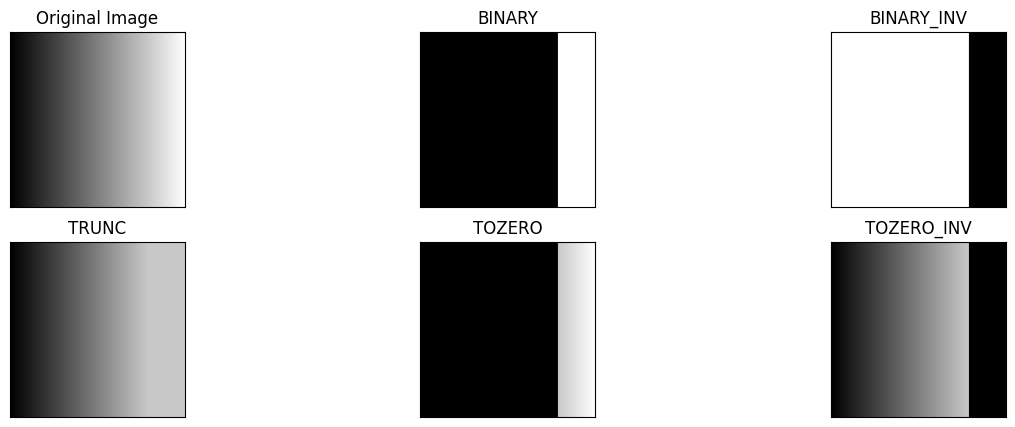

In [11]:
#3. Buat Global Threshold (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV), dengan threshold = 200

gradient_row = np.linspace(0, 255, 255, dtype=np.uint8)
img = np.tile(gradient_row, (255, 1))

thresh = 200
maxval = 255

thresh1 = np.where(img > thresh, maxval, 0).astype(np.uint8)     # BINARY
thresh2 = np.where(img > thresh, 0, maxval).astype(np.uint8)     # BINARY_INV
thresh3 = np.where(img > thresh, thresh, img).astype(np.uint8)   # TRUNC
thresh4 = np.where(img > thresh, img, 0).astype(np.uint8)        # TOZERO
thresh5 = np.where(img > thresh, 0, img).astype(np.uint8)        # TOZERO_INV

titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize=(15, 5))
for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i])
    plt.xticks([])
    plt.yticks([])
plt.show()

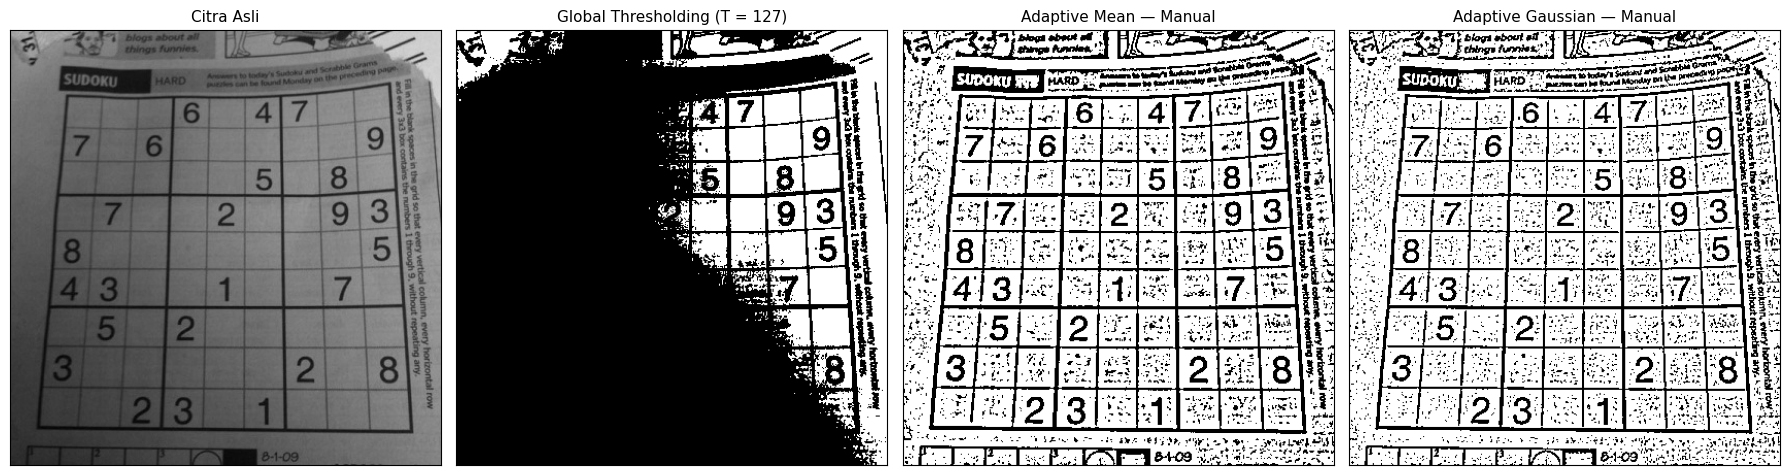

In [10]:
#4. Buat program Addaptive Threshold : adaptive mean dan adaptive Gaussian tanpa menggunakan cv.threshold(), cv.adaptiveThreshold(), maupun fungsi filter

filename = '/content/drive/MyDrive/PCVK/Images/sudoku-original.jpg'
img_bgr = cv.imread(filename)
gray = np.dot(img_bgr[..., :3], [0.114, 0.587, 0.299]).astype(np.uint8)

# Global Thresholding Manual (Threshold = 127)
thresh_val = 127
th1 = np.where(gray > thresh_val, 255, 0).astype(np.uint8)

block_size = 11
C = 2
sigma = 2
pad = block_size // 2
padded_gray = np.pad(gray, pad, mode='reflect')

x, y = np.meshgrid(np.arange(-pad, pad + 1), np.arange(-pad, pad + 1))
gaussian_kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
gaussian_kernel /= gaussian_kernel.sum()

height, width = gray.shape
th2 = np.zeros((height, width), dtype=np.uint8)  # Adaptive Mean
th3 = np.zeros((height, width), dtype=np.uint8)  # Adaptive Gaussian

for i in range(height):
    for j in range(width):
        window = padded_gray[i:i + block_size, j:j + block_size]
        mean_val = np.mean(window)
        T_mean = mean_val - C
        th2[i, j] = 255 if gray[i, j] > T_mean else 0
        gauss_val = np.sum(window * gaussian_kernel)
        T_gauss = gauss_val - C
        th3[i, j] = 255 if gray[i, j] > T_gauss else 0

titles = [
    'Citra Asli',
    'Global Thresholding (T = 127)',
    'Adaptive Mean — Manual',
    'Adaptive Gaussian — Manual'
]
citra2 = [gray, th1, th2, th3]

plt.figure(figsize=(18, 5))
for i in range(len(citra2)):
    plt.subplot(1, 4, i + 1)
    plt.imshow(citra2[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i], fontsize=11)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

/tmp/ipykernel_1607/399843505.py:22: RuntimeWarning: invalid value encountered in divide
  muf = np.sum(intensity_arr[t:]*his[t:]) / float(pcf)


114


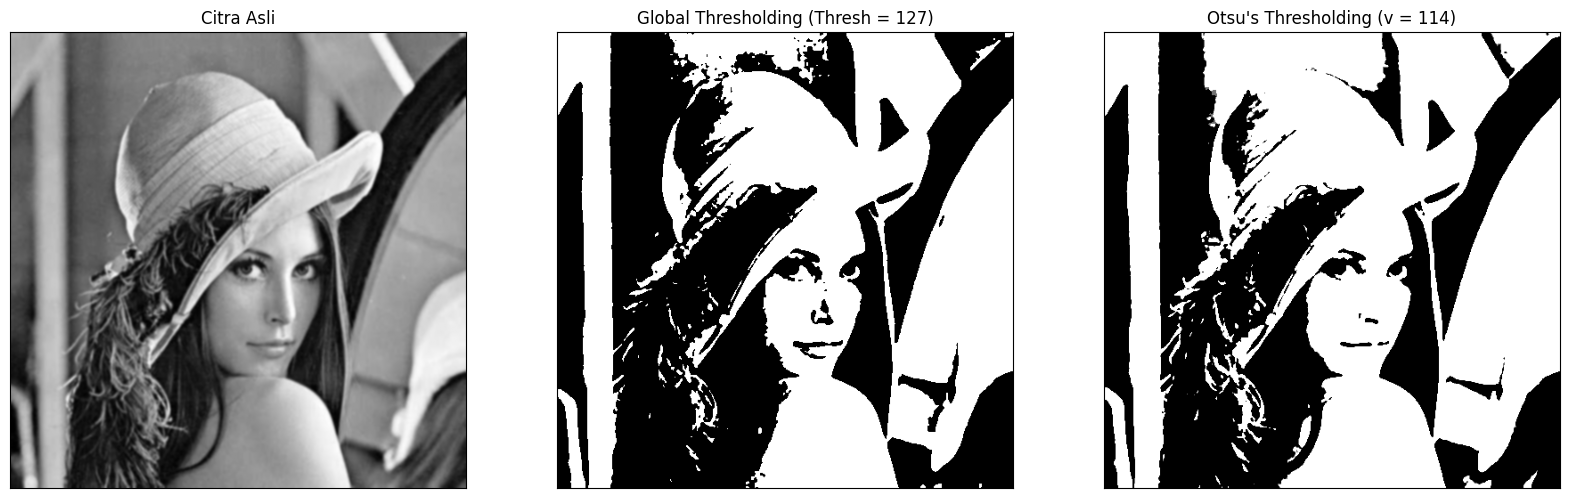

In [15]:
# 5A. Buat Otsu Thresholding tanpa menggunakan Library. Tampilkan juga nilai threshold saat anda gunakan Otsu’s

filename = ('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh=127

def otsu(gray):
    pixel_number = gray.shape[0] * gray.shape[1]
    mean_weight = 1.0/pixel_number
    his, bins = np.histogram(gray, np.arange(0,257))
    final_thresh = -1
    final_value = -1
    intensity_arr = np.arange(256)
    for t in bins[1:-1]:
        pcb = np.sum(his[:t])
        pcf = np.sum(his[t:])
        Wb = pcb * mean_weight
        Wf = pcf * mean_weight

        mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)
        muf = np.sum(intensity_arr[t:]*his[t:]) / float(pcf)
        value = Wb * Wf * (mub - muf) ** 2

        if value > final_value:
            final_thresh = t
            final_value = value
    final_img = gray.copy()
    print(final_thresh)
    final_img[gray > final_thresh] = 255
    final_img[gray < final_thresh] = 0
    return final_img, final_thresh

otsu_biner, otsu_thresh = otsu(blur)
x = ("Otsu's Thresholding (v = ")+str(otsu_thresh)+")"
ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)

titles = ['Citra Asli', 'Global Thresholding (Thresh = ' + str(thresh) +
')', x]
citra3 = [blur, th1, otsu_biner]

plt.figure(figsize = (20,15))
for i in range(len(citra3)):
    plt.subplot(1,3,i+1),plt.imshow(citra3[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

/tmp/ipykernel_1607/1188452577.py:21: RuntimeWarning: invalid value encountered in divide
  mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)


166


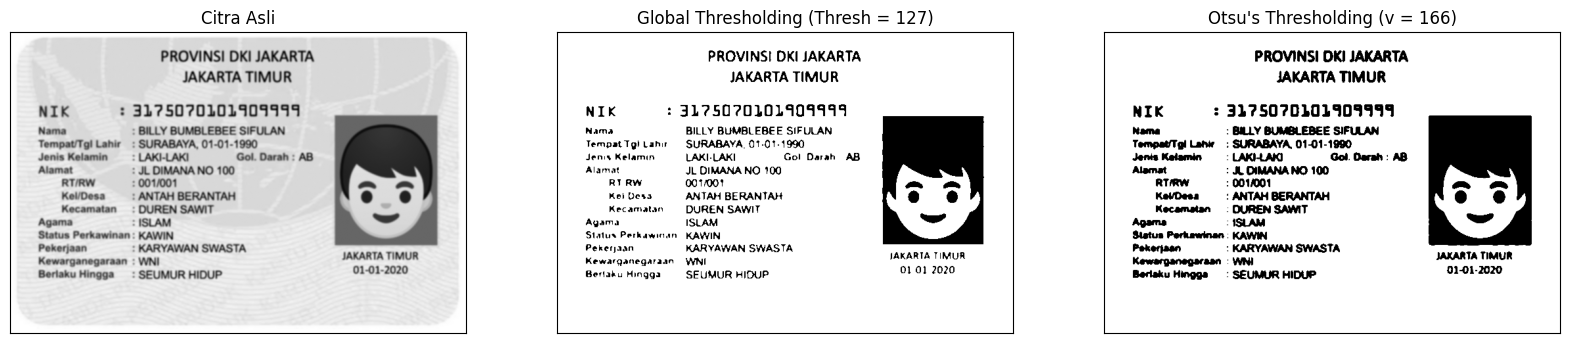

In [17]:
#5B. Kemudian coba dengan image KTP sendiri agar terlihat beda antara hasil otsu’s dengan global threshold biasa)

filename = ('/content/drive/MyDrive/PCVK/Images/ktp_fulan.jpg')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh=127

def otsu(gray):
    pixel_number = gray.shape[0] * gray.shape[1]
    mean_weight = 1.0/pixel_number
    his, bins = np.histogram(gray, np.arange(0,257))
    final_thresh = -1
    final_value = -1
    intensity_arr = np.arange(256)
    for t in bins[1:-1]:
        pcb = np.sum(his[:t])
        pcf = np.sum(his[t:])
        Wb = pcb * mean_weight
        Wf = pcf * mean_weight

        mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)
        muf = np.sum(intensity_arr[t:]*his[t:]) / float(pcf)
        value = Wb * Wf * (mub - muf) ** 2

        if value > final_value:
            final_thresh = t
            final_value = value
    final_img = gray.copy()
    print(final_thresh)
    final_img[gray > final_thresh] = 255
    final_img[gray < final_thresh] = 0
    return final_img, final_thresh

otsu_biner, otsu_thresh = otsu(blur)
x = ("Otsu's Thresholding (v = ")+str(otsu_thresh)+")"
ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)

titles = ['Citra Asli', 'Global Thresholding (Thresh = ' + str(thresh) +
')', x]
citra3 = [blur, th1, otsu_biner]

plt.figure(figsize = (20,15))
for i in range(len(citra3)):
    plt.subplot(1,3,i+1),plt.imshow(citra3[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

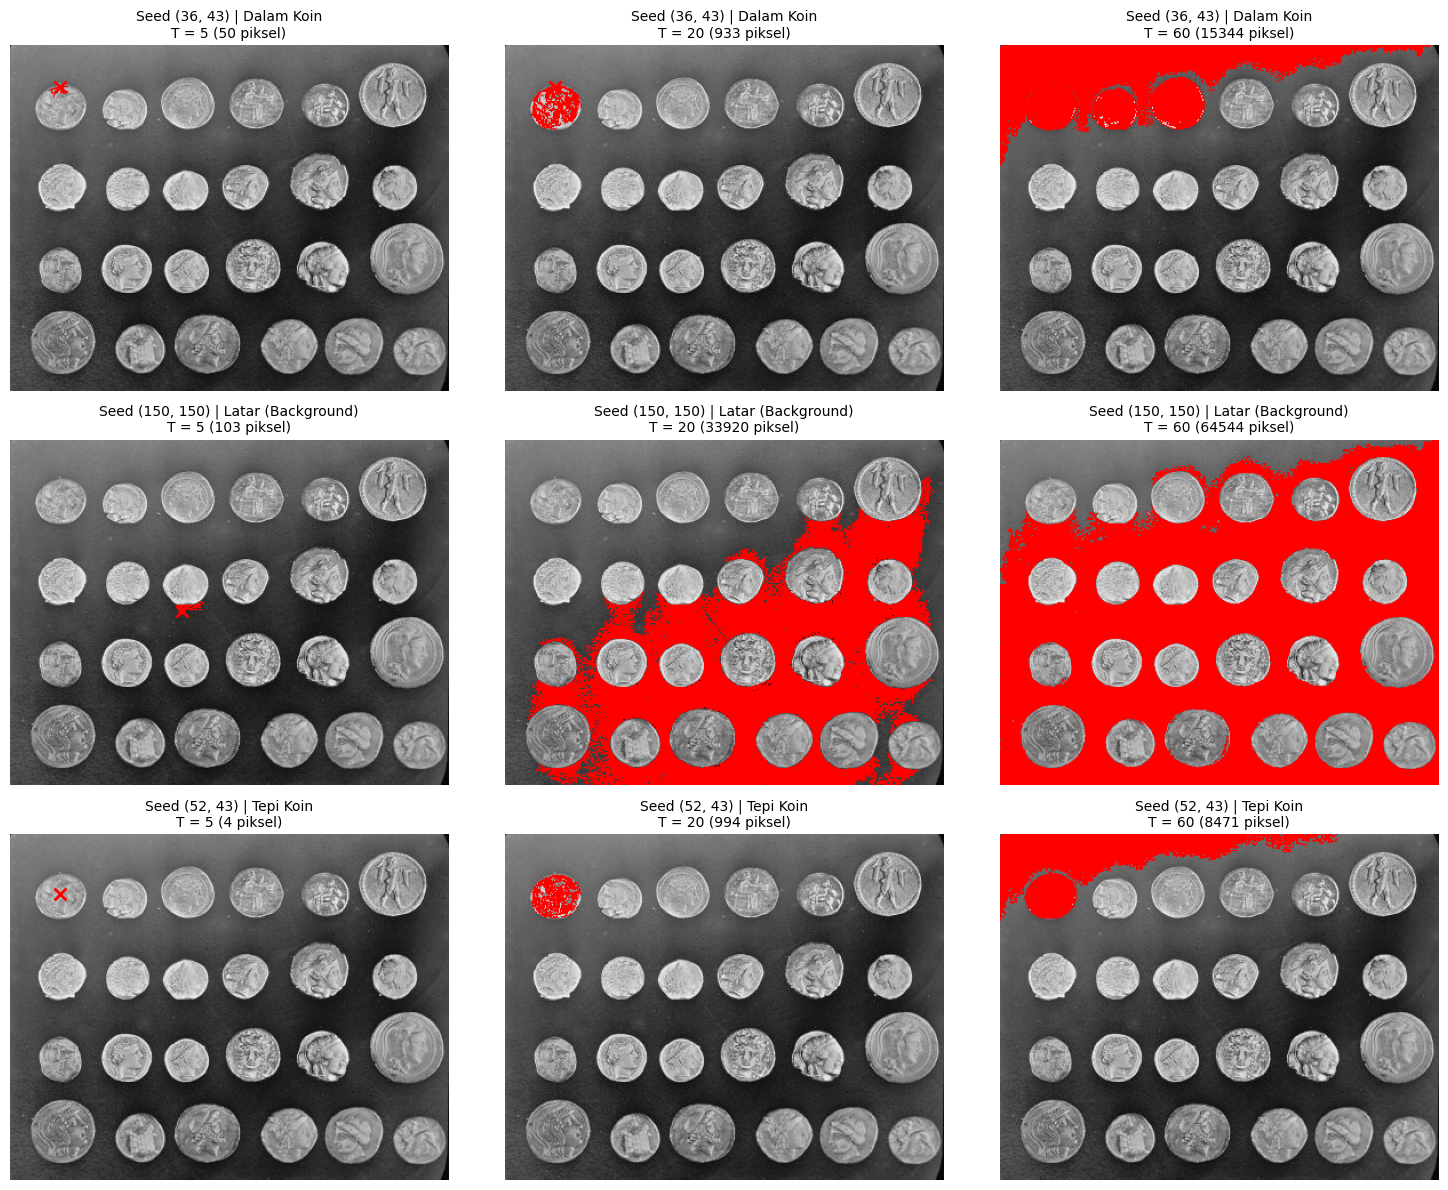

In [19]:
# 6A.

from skimage import data
img = data.coins()


# 2. Tentukan 3 titik seed (baris, kolom)
# Seed 1: Dalam koin
# Seed 2: Latar (background)
# Seed 3: Tepi/edge koin
seeds = [
    (36, 43),    # Dalam koin
    (150, 150),  # Latar (background)
    (52, 43)     # Tepi koin
]

seed_names = ["Dalam Koin", "Latar (Background)", "Tepi Koin"]
thresholds = [5, 20, 60]

# 3. Fungsi Algoritma Region Growing Manual (BFS)
def region_growing(img, seed, threshold):
    height, width = img.shape
    segmented = np.zeros((height, width), dtype=bool)
    visited = np.zeros((height, width), dtype=bool)

    sr, sc = seed
    seed_value = float(img[sr, sc])

    # Queue untuk BFS (Breadth-First Search)
    queue = deque([(sr, sc)])
    visited[sr, sc] = True

    # 8-connectivity (8 tetangga)
    neighbors = [(-1, -1), (-1, 0), (-1, 1),
                 (0, -1),           (0, 1),
                 (1, -1),  (1, 0),  (1, 1)]

    while queue:
        r, c = queue.popleft()
        segmented[r, c] = True

        for dr, dc in neighbors:
            nr, nc = r + dr, c + dc

            # Cek batas citra dan status kunjungan
            if 0 <= nr < height and 0 <= nc < width and not visited[nr, nc]:
                visited[nr, nc] = True
                # Kriteria kesamaan: selisih absolut intensitas <= threshold
                if abs(float(img[nr, nc]) - seed_value) <= threshold:
                    queue.append((nr, nc))

    return segmented

# 4. Plot Hasil Grid 3x3 (3 Seed x 3 Threshold)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, seed in enumerate(seeds):
    sr, sc = seed
    seed_val = img[sr, sc]

    for j, T in enumerate(thresholds):
        # Jalankan Region Growing
        mask = region_growing(img, seed, T)
        pixel_count = np.sum(mask)

        # Buat tampilan berwarna (merah) untuk area ter-segmentasi
        img_color = np.stack([img] * 3, axis=-1)
        img_color[mask] = [255, 0, 0]  # Warna Merah untuk region

        ax = axes[i, j]
        ax.imshow(img_color)

        # Tandai lokasi seed dengan tanda silang merah/putih
        ax.plot(sc, sr, 'rx', markersize=8, markeredgewidth=2)

        ax.set_title(
            f"Seed ({sr}, {sc}) | {seed_names[i]}\nT = {T} ({pixel_count} piksel)",
            fontsize=10
        )
        ax.axis('off')

plt.tight_layout()
plt.show()